In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [101]:
df = pd.read_parquet('features.parquet')
gmm = pd.read_parquet('gmm_regime_probabilities_oos.parquet')
hmm = pd.read_parquet('hmm_regime_probabilities_oos_filtered.parquet')
tcn_hmm = pd.read_parquet('tcn_hmm_regime_probabilities_oos_filtered.parquet')
tcn_hmm_vol = pd.read_parquet('tcn_vol_hmm_regime_probabilities.parquet')

In [50]:
regime_cols = ["p_regime_0", "p_regime_1", "p_regime_2"]
tmp = gmm.copy()
tmp["regime"] = gmm[regime_cols].values.argmax(axis=1)
tmp = tmp.merge(df[["datetime", "r"]], on="datetime", how="inner")
print(tmp.groupby("regime")["r"].mean())

regime
0   -0.000962
1    0.000098
2    0.000603
Name: r, dtype: float64


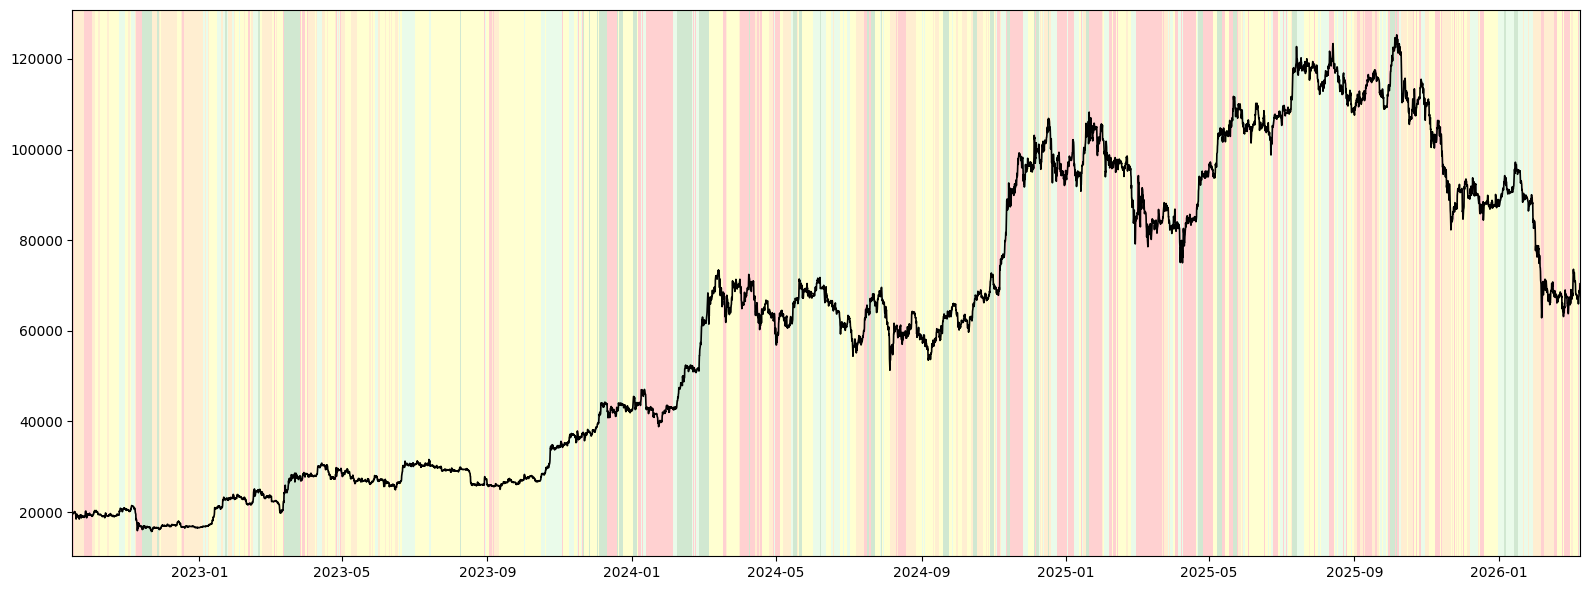

In [92]:
start = pd.Timestamp("2022-09-16 00:00:00+00:00")
end = pd.Timestamp("2026-03-10 04:00:00+00:00")

price = df.copy()
regimes = gmm.copy()

price["datetime"] = pd.to_datetime(price["datetime"], utc=True)
regimes["datetime"] = pd.to_datetime(regimes["datetime"], utc=True)

price = price[
    (price["datetime"] >= start) &
    (price["datetime"] <= end)
].sort_values("datetime")

regimes = regimes[
    (regimes["datetime"] >= start) &
    (regimes["datetime"] <= end)
].sort_values("datetime")

regime_cols = [
    "p_regime_0",
    "p_regime_1",
    "p_regime_2",
    "p_regime_3",
    "p_regime_4",
]

regimes["regime"] = (
    regimes[regime_cols]
    .idxmax(axis=1)
    .str.extract(r"(\d+)")
    .astype(int)
)
colors = {
    0: "red",
    1: "orange",
    2: "yellow",
    3: "lightgreen",
    4: "green",}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    price["datetime"],
    price["close"],
    color="black",
    linewidth=1.2,
)

for i in range(len(regimes) - 1):
    regime = regimes.iloc[i]["regime"]

    ax.axvspan(
        regimes.iloc[i]["datetime"],
        regimes.iloc[i + 1]["datetime"],
        color=colors[regime],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlim(start, end)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.grid(False)

plt.tight_layout()
plt.savefig("gmm_5regimes.png", dpi=300)
plt.show()

In [93]:
h = 24
tmp = gmm.copy()
tmp["datetime"] = pd.to_datetime(tmp["datetime"], utc=True)
tmp = tmp.merge(
    df[["datetime", "close", "r"]],
    on="datetime",
    how="left",)
tmp["regime"] = (
    tmp[[f"p_regime_{i}" for i in range(5)]]
    .to_numpy()
    .argmax(axis=1))
tmp["fwd_ret"] = (
    tmp["close"].shift(-h) / tmp["close"] - 1)
tmp.groupby("regime")["fwd_ret"].agg(
    ["count", "mean", "median", "std"])

,count,mean,median,std
regime,,,,
0,1658,0.006295,0.004901,0.043171
1,1707,-0.000184,0.001079,0.051723
2,2627,0.005320,-0.000304,0.050012
3,1353,0.004653,0.002309,0.056828
4,779,0.010130,0.003768,0.042203


In [94]:
tmp["up"] = (tmp["fwd_ret"] > 0).astype(int)
tmp.groupby("regime")["up"].mean()

regime
0    0.571773
1    0.515808
2    0.496764
3    0.521076
4    0.563543
Name: up, dtype: float64

In [95]:
stats = tmp.groupby("regime")["fwd_ret"].agg(
    mean="mean",
    std="std")
stats["sharpe"] = stats["mean"] / stats["std"]
stats

,mean,std,sharpe
regime,,,
0,0.006295,0.043171,0.145821
1,-0.000184,0.051723,-0.003548
2,0.005320,0.050012,0.106377
3,0.004653,0.056828,0.081871
4,0.010130,0.042203,0.240026


In [96]:
r = tmp["regime"]

pd.crosstab(
    r.shift(),
    r,
    normalize="index")

regime,0,1,2,3,4
regime,,,,,
0.0,0.876357,0.031363,0.054282,0.022919,0.015078
1.0,0.031616,0.879977,0.056792,0.025761,0.005855
2.0,0.031976,0.037305,0.885040,0.030453,0.015226
3.0,0.029091,0.031273,0.054545,0.872727,0.012364
4.0,0.034660,0.015404,0.050064,0.017972,0.881900


In [103]:
bt = gmm.copy()
bt["datetime"] = pd.to_datetime(bt["datetime"], utc=True)
px = df[["datetime", "r"]].copy()
px["datetime"] = pd.to_datetime(px["datetime"], utc=True)
bt = bt.merge(px, on="datetime", how="inner").sort_values("datetime")
regime_cols = [f"p_regime_{i}" for i in range(5)]
bt["regime"] = bt[regime_cols].to_numpy().argmax(axis=1)
strategies = {
    "long_4": bt["regime"].eq(4).astype(float),
    "long_3_4": bt["regime"].isin([3, 4]).astype(float),
    "long_2_3_4": bt["regime"].isin([2, 3, 4]).astype(float),
    "weighted": bt["regime"].map({0: 0.0, 1: 0.0, 2: 0.25, 3: 0.50, 4: 1.0}),
    "long_short": bt["regime"].map({0: -0.5, 1: -1.0, 2: 0.0, 3: 0.5, 4: 1.0}),}
cost = 0.0004
out = []
for name, pos in strategies.items():
    bt[name + "_pos"] = pos.shift(1).fillna(0.0)
    turnover = bt[name + "_pos"].diff().abs().fillna(0.0)
    strat_r = bt[name + "_pos"] * bt["r"] - cost * turnover
    equity = np.exp(strat_r.cumsum())
    ann = 6 * 365  
    out.append({
        "strategy": name,
        "mean_bar": strat_r.mean(),
        "ann_return": equity.iloc[-1] ** (ann / len(equity)) - 1,
        "ann_vol": strat_r.std() * np.sqrt(ann),
        "sharpe": strat_r.mean() / strat_r.std() * np.sqrt(ann),
        "max_dd": (equity / equity.cummax() - 1).min(),
        "turnover": turnover.mean(),
        "exposure": bt[name + "_pos"].abs().mean(),})
results = pd.DataFrame(out).sort_values("sharpe", ascending=False)
print(results)

     strategy  mean_bar  ann_return   ann_vol    sharpe    max_dd  turnover  \
0      long_4  0.000035    0.079240  0.158155  0.482167 -0.217606  0.022582   
3    weighted  0.000032    0.071444  0.191637  0.360095 -0.351812  0.044489   
1    long_3_4  0.000031    0.069533  0.241801  0.278007 -0.419238  0.058051   
2  long_2_3_4  0.000026    0.057908  0.334782  0.168149 -0.535316  0.074742   
4  long_short -0.000038   -0.079158  0.304425 -0.270895 -0.604885  0.102786   

   exposure  
0  0.095606  
3  0.260585  
1  0.264359  
2  0.586770  
4  0.491348  


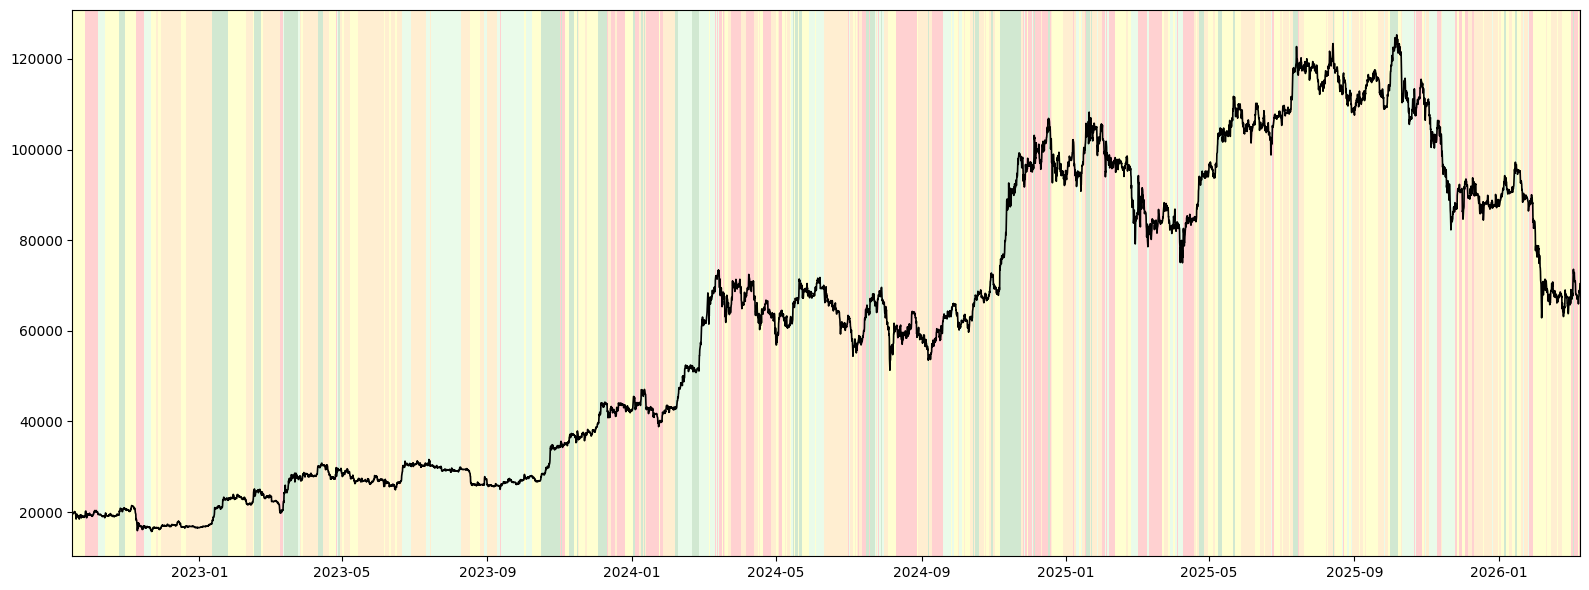

In [89]:
start = pd.Timestamp("2022-09-16 00:00:00+00:00")
end = pd.Timestamp("2026-03-10 04:00:00+00:00")

price = df.copy()
regimes = hmm.copy()

price["datetime"] = pd.to_datetime(price["datetime"], utc=True)
regimes["datetime"] = pd.to_datetime(regimes["datetime"], utc=True)

price = price[
    (price["datetime"] >= start) &
    (price["datetime"] <= end)
].sort_values("datetime")

regimes = regimes[
    (regimes["datetime"] >= start) &
    (regimes["datetime"] <= end)
].sort_values("datetime")

regime_cols = [
    "p_regime_0",
    "p_regime_1",
    "p_regime_2",
    "p_regime_3",
    "p_regime_4",
]

regimes["regime"] = (
    regimes[regime_cols]
    .idxmax(axis=1)
    .str.extract(r"(\d+)")
    .astype(int)
)
colors = {
    0: "red",
    1: "orange",
    2: "yellow",
    3: "lightgreen",
    4: "green",}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    price["datetime"],
    price["close"],
    color="black",
    linewidth=1.2,
)

for i in range(len(regimes) - 1):
    regime = regimes.iloc[i]["regime"]

    ax.axvspan(
        regimes.iloc[i]["datetime"],
        regimes.iloc[i + 1]["datetime"],
        color=colors[regime],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlim(start, end)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.grid(False)

plt.tight_layout()
plt.savefig("hmm_5regimes.png", dpi=300)
plt.show()

In [113]:
h = 24
tmp = hmm.copy()
tmp["datetime"] = pd.to_datetime(tmp["datetime"], utc=True)
tmp = tmp.merge(
    df[["datetime", "close", "r"]],
    on="datetime",
    how="left",)
tmp["regime"] = (
    tmp[[f"p_regime_{i}" for i in range(5)]]
    .to_numpy()
    .argmax(axis=1))
tmp["fwd_ret"] = (
    tmp["close"].shift(-h) / tmp["close"] - 1)
tmp.groupby("regime")["fwd_ret"].agg(
    ["count", "mean", "median", "std"])

,count,mean,median,std
regime,,,,
0,1347,0.000807,0.001686,0.051639
1,2397,0.002026,-0.000901,0.046933
2,2075,0.004417,0.003019,0.049500
3,1289,0.004522,0.002789,0.043852
4,968,0.017987,0.006880,0.059184


In [114]:
r = tmp["regime"]

pd.crosstab(
    r.shift(),
    r,
    normalize="index")

regime,0,1,2,3,4
regime,,,,,
0.0,0.930606,0.022644,0.017531,0.018262,0.010957
1.0,0.012516,0.941594,0.025448,0.013350,0.007092
2.0,0.010120,0.030843,0.940241,0.009639,0.009157
3.0,0.019380,0.022481,0.017829,0.937209,0.003101
4.0,0.020661,0.016529,0.016529,0.003099,0.943182


In [105]:
bt = hmm.copy()
bt["datetime"] = pd.to_datetime(bt["datetime"], utc=True)
px = df[["datetime", "r"]].copy()
px["datetime"] = pd.to_datetime(px["datetime"], utc=True)
bt = bt.merge(px, on="datetime", how="inner").sort_values("datetime")
regime_cols = [f"p_regime_{i}" for i in range(5)]
bt["regime"] = bt[regime_cols].to_numpy().argmax(axis=1)
strategies = {
    "long_4": bt["regime"].eq(4).astype(float),
    "long_3_4": bt["regime"].isin([3, 4]).astype(float),
    "long_2_3_4": bt["regime"].isin([2, 3, 4]).astype(float),
    "weighted": bt["regime"].map({0: 0.0, 1: 0.0, 2: 0.25, 3: 0.50, 4: 1.0}),
    "long_short": bt["regime"].map({0: -0.5, 1: -1.0, 2: 0.0, 3: 0.5, 4: 1.0}),}
cost = 0.0004
out = []
for name, pos in strategies.items():
    bt[name + "_pos"] = pos.shift(1).fillna(0.0)
    turnover = bt[name + "_pos"].diff().abs().fillna(0.0)
    strat_r = bt[name + "_pos"] * bt["r"] - cost * turnover
    equity = np.exp(strat_r.cumsum())
    ann = 6 * 365  
    out.append({
        "strategy": name,
        "mean_bar": strat_r.mean(),
        "ann_return": equity.iloc[-1] ** (ann / len(equity)) - 1,
        "ann_vol": strat_r.std() * np.sqrt(ann),
        "sharpe": strat_r.mean() / strat_r.std() * np.sqrt(ann),
        "max_dd": (equity / equity.cummax() - 1).min(),
        "turnover": turnover.mean(),
        "exposure": bt[name + "_pos"].abs().mean(),})
results = pd.DataFrame(out).sort_values("sharpe", ascending=False)
print(results)

     strategy  mean_bar  ann_return   ann_vol    sharpe    max_dd  turnover  \
2  long_2_3_4  0.000228    0.645822  0.351665  1.416805 -0.346502  0.043210   
3    weighted  0.000113    0.281130  0.209278  1.183797 -0.191937  0.025556   
1    long_3_4  0.000134    0.341064  0.259567  1.130585 -0.251146  0.031852   
4  long_short  0.000160    0.418573  0.316246  1.105629 -0.283197  0.061543   
0      long_4  0.000045    0.104767  0.176808  0.563517 -0.230953  0.013580   

   exposure  
2  0.534938  
3  0.263179  
1  0.278765  
4  0.579568  
0  0.119506  


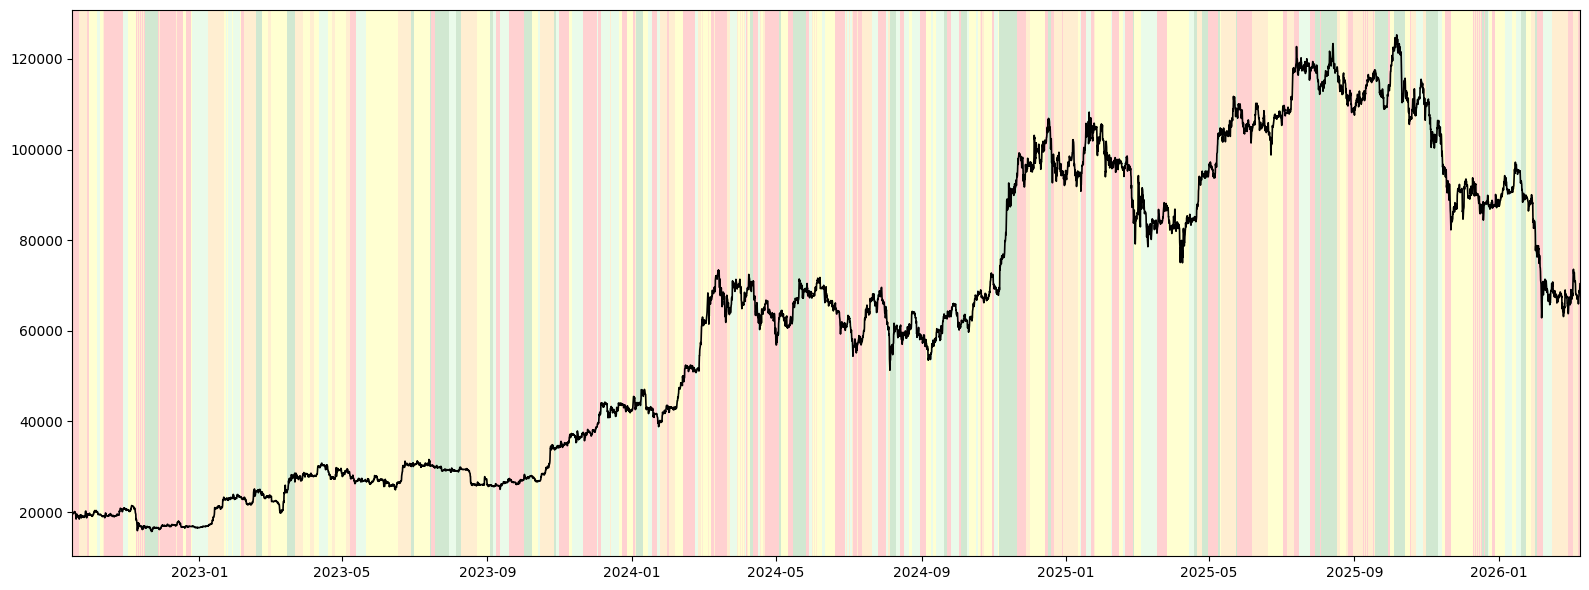

In [102]:
start = pd.Timestamp("2022-09-16 00:00:00+00:00")
end = pd.Timestamp("2026-03-10 04:00:00+00:00")

price = df.copy()
regimes = tcn_hmm.copy()

price["datetime"] = pd.to_datetime(price["datetime"], utc=True)
regimes["datetime"] = pd.to_datetime(regimes["datetime"], utc=True)

price = price[
    (price["datetime"] >= start) &
    (price["datetime"] <= end)
].sort_values("datetime")

regimes = regimes[
    (regimes["datetime"] >= start) &
    (regimes["datetime"] <= end)
].sort_values("datetime")

regime_cols = [
    "p_regime_0",
    "p_regime_1",
    "p_regime_2",
    "p_regime_3",
    "p_regime_4",
]

regimes["regime"] = (
    regimes[regime_cols]
    .idxmax(axis=1)
    .str.extract(r"(\d+)")
    .astype(int)
)
colors = {
    0: "red",
    1: "orange",
    2: "yellow",
    3: "lightgreen",
    4: "green",}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    price["datetime"],
    price["close"],
    color="black",
    linewidth=1.2,
)

for i in range(len(regimes) - 1):
    regime = regimes.iloc[i]["regime"]

    ax.axvspan(
        regimes.iloc[i]["datetime"],
        regimes.iloc[i + 1]["datetime"],
        color=colors[regime],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlim(start, end)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.grid(False)

plt.tight_layout()
plt.savefig("tcn_hmm5.png", dpi=300)
plt.show()

In [106]:
h = 24
tmp = tcn_hmm.copy()
tmp["datetime"] = pd.to_datetime(tmp["datetime"], utc=True)
tmp = tmp.merge(
    df[["datetime", "close", "r"]],
    on="datetime",
    how="left",)
tmp["regime"] = (
    tmp[[f"p_regime_{i}" for i in range(5)]]
    .to_numpy()
    .argmax(axis=1))
tmp["fwd_ret"] = (
    tmp["close"].shift(-h) / tmp["close"] - 1)
tmp.groupby("regime")["fwd_ret"].agg(
    ["count", "mean", "median", "std"])

,count,mean,median,std
regime,,,,
0,2098,0.000192,-0.000378,0.046784
1,1542,0.013884,0.006407,0.054150
2,1969,0.005835,0.002200,0.051502
3,1398,0.000544,0.002041,0.045676
4,1129,0.004220,0.001274,0.048182


In [107]:
bt = tcn_hmm.copy()
bt["datetime"] = pd.to_datetime(bt["datetime"], utc=True)
px = df[["datetime", "r"]].copy()
px["datetime"] = pd.to_datetime(px["datetime"], utc=True)
bt = bt.merge(px, on="datetime", how="inner").sort_values("datetime")
regime_cols = [f"p_regime_{i}" for i in range(5)]
bt["regime"] = bt[regime_cols].to_numpy().argmax(axis=1)
strategies = {
    "long_4": bt["regime"].eq(4).astype(float),
    "long_3_4": bt["regime"].isin([3, 4]).astype(float),
    "long_2_3_4": bt["regime"].isin([2, 3, 4]).astype(float),
    "weighted": bt["regime"].map({0: 0.0, 1: 0.0, 2: 0.25, 3: 0.50, 4: 1.0}),
    "long_short": bt["regime"].map({0: -0.5, 1: -1.0, 2: 0.0, 3: 0.5, 4: 1.0}),}
cost = 0.0004
out = []
for name, pos in strategies.items():
    bt[name + "_pos"] = pos.shift(1).fillna(0.0)
    turnover = bt[name + "_pos"].diff().abs().fillna(0.0)
    strat_r = bt[name + "_pos"] * bt["r"] - cost * turnover
    equity = np.exp(strat_r.cumsum())
    ann = 6 * 365  
    out.append({
        "strategy": name,
        "mean_bar": strat_r.mean(),
        "ann_return": equity.iloc[-1] ** (ann / len(equity)) - 1,
        "ann_vol": strat_r.std() * np.sqrt(ann),
        "sharpe": strat_r.mean() / strat_r.std() * np.sqrt(ann),
        "max_dd": (equity / equity.cummax() - 1).min(),
        "turnover": turnover.mean(),
        "exposure": bt[name + "_pos"].abs().mean(),})
results = pd.DataFrame(out).sort_values("sharpe", ascending=False)
print(results)

     strategy  mean_bar  ann_return   ann_vol    sharpe    max_dd  turnover  \
0      long_4  0.000057    0.133277  0.164028  0.762755 -0.326104  0.010417   
3    weighted  0.000048    0.111808  0.195880  0.541081 -0.325790  0.020895   
2  long_2_3_4  0.000071    0.168134  0.340117  0.456925 -0.426288  0.034681   
1    long_3_4  0.000008    0.018483  0.241745  0.075760 -0.381641  0.028064   
4  long_short -0.000043   -0.089125  0.305984 -0.305079 -0.533052  0.059314   

   exposure  
0  0.141176  
3  0.287163  
2  0.553799  
1  0.312500  
4  0.544363  


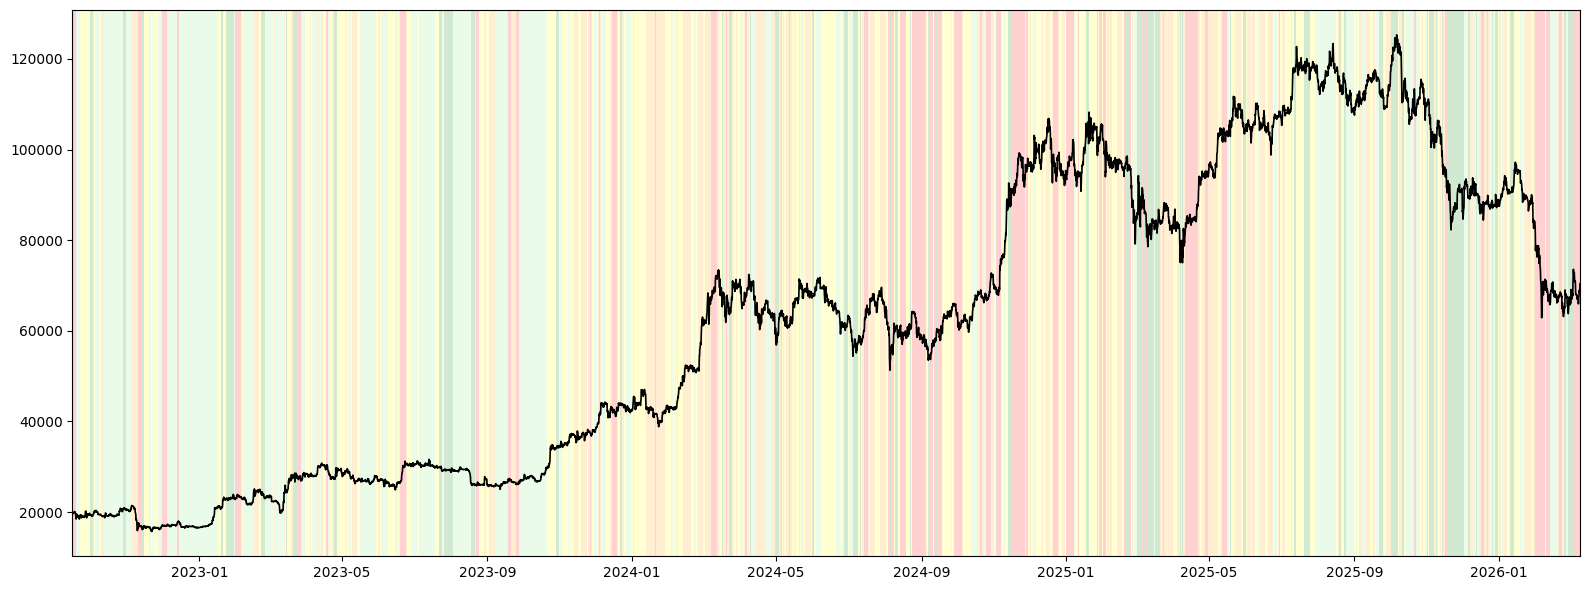

In [112]:
start = pd.Timestamp("2022-09-16 00:00:00+00:00")
end = pd.Timestamp("2026-03-10 04:00:00+00:00")

price = df.copy()
regimes = tcn_hmm_vol.copy()

price["datetime"] = pd.to_datetime(price["datetime"], utc=True)
regimes["datetime"] = pd.to_datetime(regimes["datetime"], utc=True)

price = price[
    (price["datetime"] >= start) &
    (price["datetime"] <= end)
].sort_values("datetime")

regimes = regimes[
    (regimes["datetime"] >= start) &
    (regimes["datetime"] <= end)
].sort_values("datetime")

regime_cols = [
    "p_regime_0",
    "p_regime_1",
    "p_regime_2",
    "p_regime_3",
    "p_regime_4",
]

regimes["regime"] = (
    regimes[regime_cols]
    .idxmax(axis=1)
    .str.extract(r"(\d+)")
    .astype(int)
)
colors = {
    0: "red",
    1: "orange",
    2: "yellow",
    3: "lightgreen",
    4: "green",}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    price["datetime"],
    price["close"],
    color="black",
    linewidth=1.2,
)

for i in range(len(regimes) - 1):
    regime = regimes.iloc[i]["regime"]

    ax.axvspan(
        regimes.iloc[i]["datetime"],
        regimes.iloc[i + 1]["datetime"],
        color=colors[regime],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlim(start, end)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.grid(False)

plt.tight_layout()
plt.savefig("tcn_hmm_vol_5regimes.png", dpi=300)
plt.show()

In [109]:
h = 24
tmp = tcn_hmm_vol.copy()
tmp["datetime"] = pd.to_datetime(tmp["datetime"], utc=True)
tmp = tmp.merge(
    df[["datetime", "close", "r"]],
    on="datetime",
    how="left",)
tmp["regime"] = (
    tmp[[f"p_regime_{i}" for i in range(5)]]
    .to_numpy()
    .argmax(axis=1))
tmp["fwd_ret"] = (
    tmp["close"].shift(-h) / tmp["close"] - 1)
tmp.groupby("regime")["fwd_ret"].agg(
    ["count", "mean", "median", "std"])

,count,mean,median,std
regime,,,,
0,1125,0.002486,0.003779,0.052795
1,1749,0.002440,-0.000338,0.051229
2,2073,0.005965,0.001566,0.048745
3,2097,0.005068,0.002480,0.050997
4,1032,0.008035,0.004695,0.042895


In [111]:
bt = tcn_hmm_vol.copy()
bt["datetime"] = pd.to_datetime(bt["datetime"], utc=True)
px = df[["datetime", "r"]].copy()
px["datetime"] = pd.to_datetime(px["datetime"], utc=True)
bt = bt.merge(px, on="datetime", how="inner").sort_values("datetime")
regime_cols = [f"p_regime_{i}" for i in range(5)]
bt["regime"] = bt[regime_cols].to_numpy().argmax(axis=1)
strategies = {
    "long_4": bt["regime"].eq(4).astype(float),
    "long_3_4": bt["regime"].isin([3, 4]).astype(float),
    "long_2_3_4": bt["regime"].isin([2, 3, 4]).astype(float),
    "weighted": bt["regime"].map({0: 0.0, 1: 0.0, 2: 0.25, 3: 0.50, 4: 1.0}),
    "long_short": bt["regime"].map({0: -0.5, 1: -1.0, 2: 0.0, 3: 0.5, 4: 1.0}),}
cost = 0.0004
out = []
for name, pos in strategies.items():
    bt[name + "_pos"] = pos.shift(1).fillna(0.0)
    turnover = bt[name + "_pos"].diff().abs().fillna(0.0)
    strat_r = bt[name + "_pos"] * bt["r"] - cost * turnover
    equity = np.exp(strat_r.cumsum())
    ann = 6 * 365  
    out.append({
        "strategy": name,
        "mean_bar": strat_r.mean(),
        "ann_return": equity.iloc[-1] ** (ann / len(equity)) - 1,
        "ann_vol": strat_r.std() * np.sqrt(ann),
        "sharpe": strat_r.mean() / strat_r.std() * np.sqrt(ann),
        "max_dd": (equity / equity.cummax() - 1).min(),
        "turnover": turnover.mean(),
        "exposure": bt[name + "_pos"].abs().mean(),})
results = pd.DataFrame(out).sort_values("sharpe", ascending=False)
print(results)

     strategy  mean_bar  ann_return   ann_vol    sharpe    max_dd  turnover  \
0      long_4  0.000081    0.194114  0.195558  0.907169 -0.185212  0.019259   
3    weighted  0.000088    0.213421  0.226774  0.853025 -0.230411  0.028951   
2  long_2_3_4  0.000131    0.332104  0.361987  0.792182 -0.307555  0.037778   
4  long_short  0.000072    0.171462  0.326139  0.485229 -0.469944  0.067160   
1    long_3_4  0.000060    0.141344  0.278673  0.474414 -0.344494  0.039506   

   exposure  
0  0.127407  
3  0.320957  
2  0.642716  
4  0.544568  
1  0.386296  
